<a href="https://colab.research.google.com/github/nithinpranav292-code/Ml_assignment/blob/main/exp3/sceanrio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Linear Regression Performance
MSE : 206.5671210762013
RMSE: 14.372443114383904
R2 Score: 0.03638368478697196

Regression Coefficients:
study_hours          -0.863539
attendance           -0.648245
parental_education   -1.075209
test_prep            -3.838889
sleep_hours           0.569084
dtype: float64

Ridge R2: 0.03640733697323384
Lasso R2: 0.03563451811326457


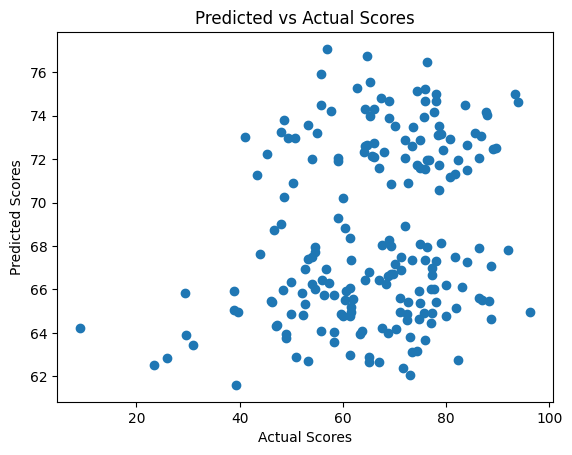

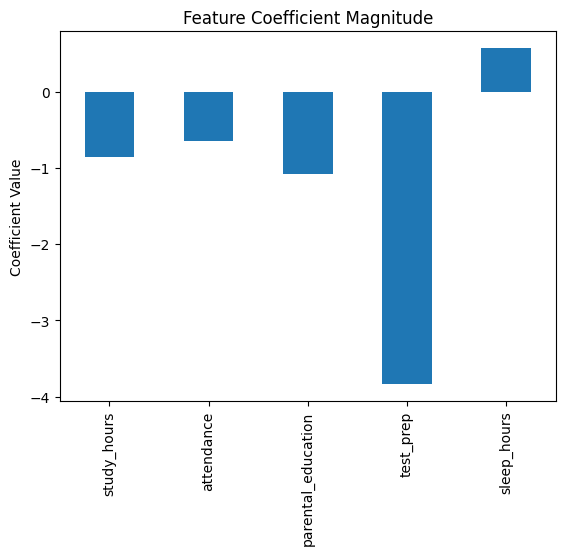

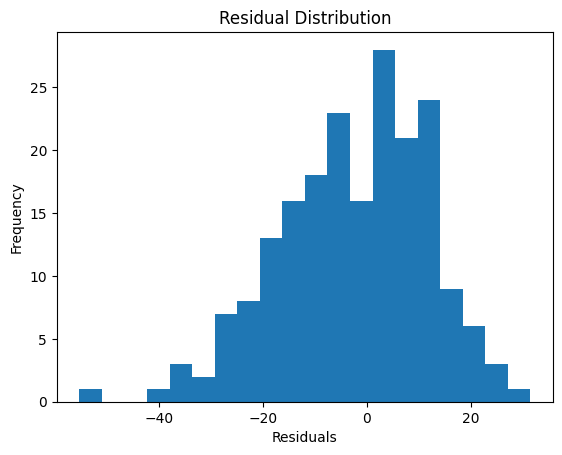

In [2]:
# ================================
# MULTILINEAR REGRESSION - STUDENT PERFORMANCE
# ================================

# 1. Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

# 2. Load dataset
df = pd.read_csv("/content/sample_data/StudentsPerformance.csv")

# 3. Preprocessing & Encoding
# Create target variable (Final Exam Score)
df["final_score"] = df[["math score", "reading score", "writing score"]].mean(axis=1)

# Encode categorical features
le = LabelEncoder()
df["parental level of education"] = le.fit_transform(df["parental level of education"])
df["test preparation course"] = le.fit_transform(df["test preparation course"])

# NOTE:
# Since Kaggle dataset doesn't contain study hours, attendance, sleep hours,
# we simulate them for lab demonstration

np.random.seed(42)
df["study_hours"] = np.random.uniform(1, 6, len(df))
df["attendance"] = np.random.uniform(60, 100, len(df))
df["sleep_hours"] = np.random.uniform(4, 9, len(df))

# 4. Select features and target
X = df[["study_hours", "attendance",
        "parental level of education",
        "test preparation course",
        "sleep_hours"]]

y = df["final_score"]

# 5. Handle missing values
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

# 6. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 8. Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 9. Predictions
y_pred = model.predict(X_test)

# 10. Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance")
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# 11. Regression Coefficients
coefficients = pd.Series(model.coef_,
                         index=["study_hours", "attendance",
                                "parental_education",
                                "test_prep",
                                "sleep_hours"])

print("\nRegression Coefficients:")
print(coefficients)

# 12. Regularization (Ridge & Lasso)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

print("\nRidge R2:", r2_score(y_test, ridge_pred))
print("Lasso R2:", r2_score(y_test, lasso_pred))

# ================================
# VISUALIZATIONS
# ================================

# Predicted vs Actual
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Predicted vs Actual Scores")
plt.show()

# Coefficient Comparison
plt.figure()
coefficients.plot(kind='bar')
plt.title("Feature Coefficient Magnitude")
plt.ylabel("Coefficient Value")
plt.show()

# Residual Distribution
residuals = y_test - y_pred
plt.figure()
plt.hist(residuals, bins=20)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

/tmp/ipython-input-500224974.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(X.mean(), inplace=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature

Model Performance Comparison

Degree 1
MSE : 22.153237123863413
RMSE: 4.706722545876633
R2 Score: 0.5659681822256185
----------------------------------------
Degree 2
MSE : 18.41696779601779
RMSE: 4.291499481069267
R2 Score: 0.6391701147013311
----------------------------------------
Degree 3
MSE : 18.460267222224626
RMSE: 4.296541309265469
R2 Score: 0.6383217814053861
----------------------------------------
Degree 4
MSE : 18.268226874853184
RMSE: 4.274134634619409
R2 Score: 0.6420842844016577
----------------------------------------
Ridge Regression (Degree 4)
R2 Score: 0.6417265483369174


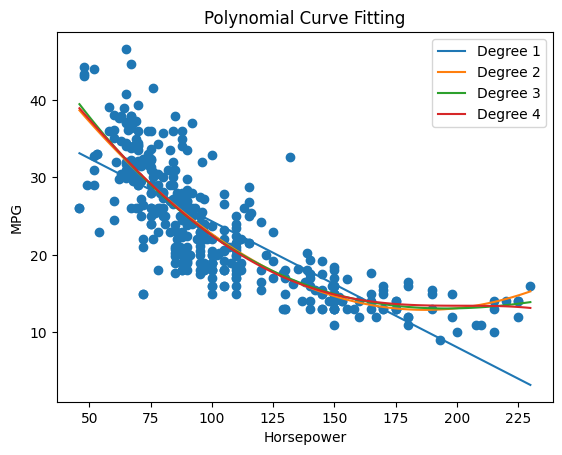

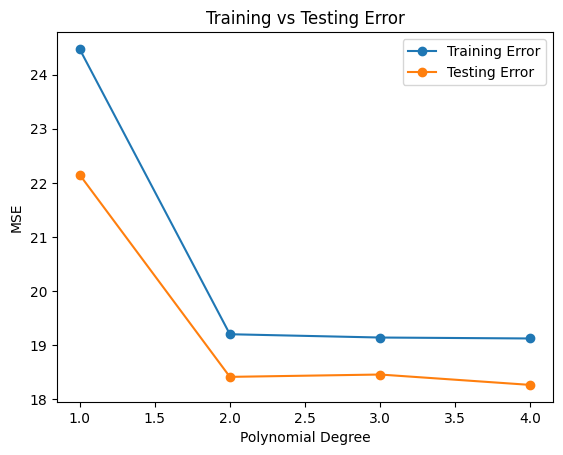

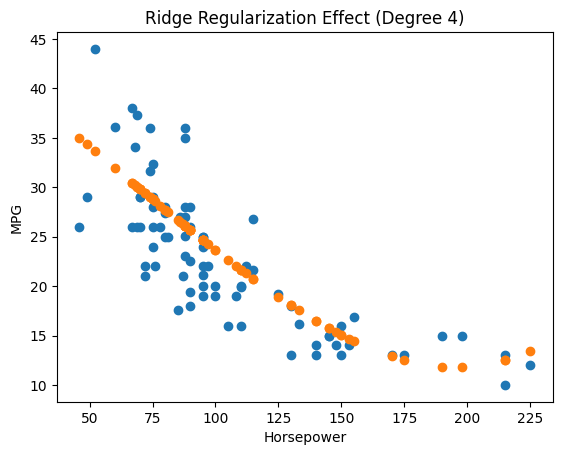

In [3]:
# ==========================================================
# POLYNOMIAL REGRESSION – AUTO MPG DATASET
# Roll Number: YOUR_ROLL_NUMBER
# ==========================================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# 2. Load Dataset
df = pd.read_csv("/content/sample_data/auto-mpg.csv")

# 3. Clean Dataset
df.replace("?", np.nan, inplace=True)
df["horsepower"] = pd.to_numeric(df["horsepower"], errors='coerce')
df.dropna(subset=["horsepower", "mpg"], inplace=True)

# 4. Select Feature and Target
X = df[["horsepower"]]
y = df["mpg"]

# 5. Handle Missing Values (mean imputation)
X.fillna(X.mean(), inplace=True)

# 6. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Store results
degrees = [1, 2, 3, 4]
train_errors = []
test_errors = []

print("Model Performance Comparison\n")

# 7–10. Train Polynomial Models
for degree in degrees:

    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("scaler", StandardScaler()),
        ("reg", LinearRegression())
    ])

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_test_pred)

    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mse)

    print(f"Degree {degree}")
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("-" * 40)

# 12. Ridge Regression (Degree 4)
ridge_model = Pipeline([
    ("poly", PolynomialFeatures(degree=4)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10))
])

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

print("Ridge Regression (Degree 4)")
print("R2 Score:", r2_score(y_test, ridge_pred))
print("=" * 40)

# ==========================================================
# VISUALIZATIONS
# ==========================================================

# 1️⃣ Polynomial Curve Fitting
plt.figure()
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

for degree in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("scaler", StandardScaler()),
        ("reg", LinearRegression())
    ])
    model.fit(X_train, y_train)
    plt.plot(X_range, model.predict(X_range), label=f"Degree {degree}")

plt.scatter(X, y)
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Polynomial Curve Fitting")
plt.legend()
plt.show()


# 2️⃣ Training vs Testing Error
plt.figure()
plt.plot(degrees, train_errors, marker='o', label="Training Error")
plt.plot(degrees, test_errors, marker='o', label="Testing Error")
plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Training vs Testing Error")
plt.legend()
plt.show()


# 3️⃣ Overfitting Demonstration (Degree 4 without Ridge vs Ridge)
plt.figure()
plt.scatter(X_test, y_test)
plt.scatter(X_test, ridge_pred)
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Ridge Regularization Effect (Degree 4)")
plt.show()